<a href="https://www.kaggle.com/code/mrrogueknight/receiptiq?scriptVersionId=312696239" target="_blank"><img align="left" alt="Kaggle" title="Open in Kaggle" src="https://kaggle.com/static/images/open-in-kaggle.svg"></a>

In [1]:
import os

# Show only first 20 files
count = 0
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))
        count += 1
        if count >= 20:
            print("... more files hidden")
            break
    if count >= 20:
        break

/kaggle/input/datasets/urbikn/sroie-datasetv2/SROIE2019/layoutlm-base-uncased/config.json
/kaggle/input/datasets/urbikn/sroie-datasetv2/SROIE2019/layoutlm-base-uncased/training_args.bin
/kaggle/input/datasets/urbikn/sroie-datasetv2/SROIE2019/layoutlm-base-uncased/tokenizer_config.json
/kaggle/input/datasets/urbikn/sroie-datasetv2/SROIE2019/layoutlm-base-uncased/pytorch_model.bin
/kaggle/input/datasets/urbikn/sroie-datasetv2/SROIE2019/layoutlm-base-uncased/special_tokens_map.json
/kaggle/input/datasets/urbikn/sroie-datasetv2/SROIE2019/layoutlm-base-uncased/vocab.txt
/kaggle/input/datasets/urbikn/sroie-datasetv2/SROIE2019/test/box/X51006008082.txt
/kaggle/input/datasets/urbikn/sroie-datasetv2/SROIE2019/test/box/X51008099090.txt
/kaggle/input/datasets/urbikn/sroie-datasetv2/SROIE2019/test/box/X51005806692.txt
/kaggle/input/datasets/urbikn/sroie-datasetv2/SROIE2019/test/box/X51006733495.txt
/kaggle/input/datasets/urbikn/sroie-datasetv2/SROIE2019/test/box/X51007846387.txt
/kaggle/input/data

# Cell 1: SROIE2019 Receipt Dataset Analysis

In [2]:
# ==========================================
# Professional Kaggle Dataset Analyzer
# SROIE2019 Receipt Dataset
# ==========================================

import os
from pathlib import Path
import pandas as pd

DATASET = Path("/kaggle/input/datasets/urbikn/sroie-datasetv2/SROIE2019")

# ------------------------------------------
# Helper Functions
# ------------------------------------------

def count_files(folder):
    return sum(1 for f in folder.rglob("*") if f.is_file())

def folder_size_mb(folder):
    total = sum(f.stat().st_size for f in folder.rglob("*") if f.is_file())
    return round(total / (1024**2), 2)

def sample_files(folder, n=3):
    files = [str(f.relative_to(DATASET)) for f in folder.rglob("*") if f.is_file()]
    return ", ".join(files[:n])

# ------------------------------------------
# Summary Table
# ------------------------------------------

rows = []

for item in sorted(DATASET.iterdir()):
    if item.is_dir():
        rows.append({
            "Folder": item.name,
            "Total Files": count_files(item),
            "Size (MB)": folder_size_mb(item),
            "Sample Files": sample_files(item)
        })

summary_df = pd.DataFrame(rows)

print("=" * 70)
print("DATASET SUMMARY")
print("=" * 70)
display(summary_df)

# ------------------------------------------
# Detailed Structure
# ------------------------------------------

print("\n" + "=" * 70)
print("FOLDER STRUCTURE")
print("=" * 70)

for item in sorted(DATASET.iterdir()):
    if item.is_dir():
        print(f"\nFolder Name : {item.name}")
        print(f"Total Files : {count_files(item)}")
        print(f"Size (MB)   : {folder_size_mb(item)}")

        subfolders = [x.name for x in item.iterdir() if x.is_dir()]
        files = [x.name for x in item.iterdir() if x.is_file()]

        if subfolders:
            print("Subfolders  :", ", ".join(subfolders[:10]))

        if files:
            print("Files       :", ", ".join(files[:10]))

# ------------------------------------------
# SROIE Specific Validation
# ------------------------------------------

print("\n" + "=" * 70)
print("SROIE DATA VALIDATION")
print("=" * 70)

test_box = DATASET / "test" / "box"

if test_box.exists():
    txt_files = list(test_box.glob("*.txt"))
    print("Test Annotation Files :", len(txt_files))
    print("Sample Files          :", ", ".join([f.name for f in txt_files[:10]]))

model_dir = DATASET / "layoutlm-base-uncased"

if model_dir.exists():
    print("\nPretrained Model Directory Found")
    print("Contained Files:")

    for f in sorted(model_dir.iterdir()):
        print("-", f.name)

print("\nAnalysis Complete")

DATASET SUMMARY


,Folder,Total Files,Size (MB),Sample Files
0,layoutlm-base-uncased,6,432.29,"layoutlm-base-uncased/config.json, layoutlm-ba..."
1,test,1041,197.11,"test/box/X51006008082.txt, test/box/X510080990..."
2,train,1878,339.97,"train/box/X51005705760.txt, train/box/X5100536..."



FOLDER STRUCTURE

Folder Name : layoutlm-base-uncased
Total Files : 6
Size (MB)   : 432.29
Files       : config.json, training_args.bin, tokenizer_config.json, pytorch_model.bin, special_tokens_map.json, vocab.txt

Folder Name : test
Total Files : 1041
Size (MB)   : 197.11
Subfolders  : box, entities, img

Folder Name : train
Total Files : 1878
Size (MB)   : 339.97
Subfolders  : box, entities, img

SROIE DATA VALIDATION
Test Annotation Files : 347
Sample Files          : X51006008082.txt, X51008099090.txt, X51005806692.txt, X51006733495.txt, X51007846387.txt, X51005337867.txt, X51006912998.txt, X51006414425.txt, X51006387660.txt, X51005745213.txt

Pretrained Model Directory Found
Contained Files:
- config.json
- pytorch_model.bin
- special_tokens_map.json
- tokenizer_config.json
- training_args.bin
- vocab.txt

Analysis Complete


# EXPENSE TRACKER

In [3]:
import gradio as gr
from PIL import Image
import easyocr
import cv2
import re
import numpy as np
from datetime import datetime
import hashlib
from collections import defaultdict, deque
from typing import Dict, List, Optional, Tuple
import pandas as pd
import os

# Suppress deprecation warnings
import warnings
warnings.filterwarnings('ignore')

# ============================================
# BACKEND LOGIC
# ============================================

class ReceiptManager:
    def __init__(self):
        self.receipts: List[Dict] = []
        self.receipt_index: set = set()
        self.category_totals: Dict[str, float] = defaultdict(float)
        self.store_totals: Dict[str, float] = defaultdict(float)
        self.monthly_totals: Dict[str, float] = defaultdict(float)
        self.recent_receipts: deque = deque(maxlen=20)
        self.total_spent: float = 0.0
        self.receipt_count: int = 0
        
    def add_receipt(self, receipt: Dict) -> bool:
        key = f"{receipt['store']}|{receipt['date']}|{receipt['amount']:.2f}"
        if key in self.receipt_index:
            return False
        self.receipts.append(receipt)
        self.receipt_index.add(key)
        self.receipt_count += 1
        self.total_spent += receipt['amount']
        self.category_totals[receipt['category']] += receipt['amount']
        self.store_totals[receipt['store']] += receipt['amount']
        month_key = receipt['date'][:7]
        self.monthly_totals[month_key] += receipt['amount']
        self.recent_receipts.appendleft(receipt)
        return True
    
    def clear_all(self):
        self.receipts.clear()
        self.receipt_index.clear()
        self.category_totals.clear()
        self.store_totals.clear()
        self.monthly_totals.clear()
        self.recent_receipts.clear()
        self.total_spent = 0.0
        self.receipt_count = 0
    
    def get_total(self) -> float:
        return self.total_spent
    
    def get_average(self) -> float:
        return self.total_spent / self.receipt_count if self.receipt_count > 0 else 0.0
    
    def get_monthly(self) -> float:
        current_month = datetime.now().strftime("%Y-%m")
        return self.monthly_totals.get(current_month, 0.0)
    
    def get_top_category(self) -> Tuple[str, float]:
        if not self.category_totals:
            return ("None", 0.0)
        return max(self.category_totals.items(), key=lambda x: x[1])
    
    def get_recent(self, limit: int = 5) -> List[Dict]:
        return list(self.recent_receipts)[:limit]
    
    def get_category_breakdown(self) -> Dict[str, float]:
        return dict(self.category_totals)

class OCRProcessor:
    _instance = None
    _reader = None
    
    def __new__(cls):
        if cls._instance is None:
            cls._instance = super().__new__(cls)
        return cls._instance
    
    @classmethod
    def get_reader(cls):
        if cls._reader is None:
            try:
                cls._reader = easyocr.Reader(['en'], gpu=False, verbose=False)
            except Exception:
                cls._reader = None
        return cls._reader
    
    def process(self, image: np.ndarray) -> Tuple[Optional[Dict], Optional[str]]:
        reader = self.get_reader()
        if reader is None:
            return None, "OCR engine unavailable"
        
        try:
            if len(image.shape) == 3:
                gray = cv2.cvtColor(image, cv2.COLOR_RGB2GRAY)
            else:
                gray = image
            
            results = reader.readtext(gray, paragraph=False)
            if not results:
                return None, "No text detected"
            
            text_lines = [r[1] for r in results]
            full_text = " ".join(text_lines).lower()
            
            store = "Unknown Store"
            for line in text_lines[:5]:
                if len(line) > 3 and not any(c.isdigit() for c in line[:2]) and len(line) < 40:
                    store = line.strip()
                    break
            
            amounts = re.findall(r'(\d+\.\d{2})', full_text)
            total = max([float(a) for a in amounts]) if amounts else 0.0
            
            if total == 0:
                return None, "No amount found"
            
            date_match = re.search(r'(\d{1,2}[/-]\d{1,2}[/-]\d{2,4})', full_text)
            date = date_match.group(1) if date_match else datetime.now().strftime("%Y-%m-%d")
            
            categories = {
                "Groceries": ["mart", "grocery", "market", "walmart", "kroger", "aldi", "whole foods"],
                "Food & Dining": ["restaurant", "cafe", "food", "dining", "starbucks", "mcdonald", "pizza"],
                "Shopping": ["mall", "shop", "amazon", "target", "best buy"],
                "Transport": ["uber", "lyft", "taxi", "bus", "train", "petrol", "gas"],
                "Bills": ["electricity", "water", "internet", "phone", "netflix"],
                "Healthcare": ["pharmacy", "clinic", "hospital", "doctor", "medicine"]
            }
            
            category = "Shopping"
            for cat, keywords in categories.items():
                if any(kw in full_text for kw in keywords):
                    category = cat
                    break
            
            return {
                "id": hashlib.md5(f"{store}{date}{total}".encode()).hexdigest()[:8],
                "store": store.title(),
                "date": date,
                "amount": total,
                "category": category,
                "timestamp": datetime.now().isoformat()
            }, None
        except Exception as e:
            return None, str(e)

receipt_manager = ReceiptManager()
ocr_processor = OCRProcessor()

# ============================================
# CHAT RESPONSES
# ============================================

def get_summary():
    if receipt_manager.receipt_count == 0:
        return "No receipts yet. Upload your first receipt."
    top_cat, top_amt = receipt_manager.get_top_category()
    return f"""**Expense Summary**

Total Spent: **${receipt_manager.get_total():,.2f}**
Receipts: **{receipt_manager.receipt_count}**
Average: **${receipt_manager.get_average():,.2f}**
Top Category: **{top_cat}** (${top_amt:,.2f})"""

def get_recent():
    recent = receipt_manager.get_recent(5)
    if not recent:
        return "No receipts yet."
    return "**Recent Receipts**\n\n" + "\n".join([f"• **{r['store']}** — ${r['amount']:.2f} ({r['date']})" for r in recent])

def get_categories():
    cats = receipt_manager.get_category_breakdown()
    if not cats:
        return "No categories yet."
    total = receipt_manager.get_total()
    return "**Category Breakdown**\n\n" + "\n".join([f"• **{cat}:** ${amt:,.2f} ({amt/total*100:.0f}%)" for cat, amt in sorted(cats.items(), key=lambda x: x[1], reverse=True)])

def get_monthly():
    if receipt_manager.receipt_count == 0:
        return "No receipts yet."
    monthly = receipt_manager.get_monthly()
    return f"**This Month**\n\n${monthly:,.2f}"

def get_advice():
    if receipt_manager.receipt_count == 0:
        return "Upload receipts to get advice."
    top_cat, _ = receipt_manager.get_top_category()
    tips = {
        "Groceries": "Plan meals and use a shopping list to avoid impulse purchases.",
        "Food & Dining": "Cook at home 2 more days per week to save significantly.",
        "Shopping": "Wait 24 hours before non-essential purchases.",
        "Transport": "Consider public transit or carpooling to reduce costs.",
        "Bills": "Review and cancel unused subscriptions monthly.",
        "Healthcare": "Compare prices at different pharmacies for medications."
    }
    return f"**Savings Tip**\n\n{tips.get(top_cat, 'Set monthly budgets for each category to track spending effectively.')}"

# ============================================
# MULTI-RECEIPT UPLOAD
# ============================================

def process_multiple_uploads(files, history):
    """Process multiple receipts at once"""
    if not files:
        return history, ""
    
    processed_count = 0
    duplicate_count = 0
    failed_count = 0
    total_amount = 0.0
    receipts_data = []
    
    for file in files:
        try:
            image = Image.open(file.name)
            img_array = np.array(image)
            receipt_data, error = ocr_processor.process(img_array)
            
            if error or receipt_data is None:
                failed_count += 1
                continue
            
            if receipt_manager.add_receipt(receipt_data):
                processed_count += 1
                total_amount += receipt_data['amount']
                receipts_data.append(receipt_data)
            else:
                duplicate_count += 1
        except Exception:
            failed_count += 1
    
    # User message
    file_msg = f"📎 Uploaded {len(files)} receipt(s)"
    history.append({"role": "user", "content": file_msg})
    
    # Assistant response
    if processed_count > 0:
        response = f"""**Processed {processed_count} receipts**

**Total detected:** ${total_amount:,.2f}"""
        if duplicate_count > 0:
            response += f"\n**{duplicate_count} duplicate(s) skipped**"
        if failed_count > 0:
            response += f"\n**{failed_count} failed to process**"
        
        from collections import Counter
        categories = [r['category'] for r in receipts_data]
        if categories:
            top_cat = Counter(categories).most_common(1)[0][0]
            response += f"\n\n**Top category:** {top_cat}"
        
        response += f"\n\n**Total spent:** ${receipt_manager.get_total():,.2f}\n**Receipts count:** {receipt_manager.receipt_count}"
    else:
        response = "❌ No receipts could be processed. Please ensure images are clear."
    
    history.append({"role": "assistant", "content": response})
    return history, ""

def send_message(message, history):
    if not message or not message.strip():
        return history, ""
    
    msg = message.lower()
    history.append({"role": "user", "content": message})
    
    if receipt_manager.receipt_count == 0:
        response = "No receipts yet. Upload receipts to get started."
    elif "summary" in msg or "total" in msg:
        response = get_summary()
    elif "recent" in msg:
        response = get_recent()
    elif "category" in msg:
        response = get_categories()
    elif "month" in msg:
        response = get_monthly()
    elif "advice" in msg or "tip" in msg:
        response = get_advice()
    else:
        response = f"""I can help with your {receipt_manager.receipt_count} receipts (${receipt_manager.get_total():.2f} total).

**Try these commands:**
• **summary** - Complete expense report
• **recent** - Last 5 receipts
• **categories** - Spending breakdown
• **this month** - Monthly total
• **advice** - Savings tips"""
    
    history.append({"role": "assistant", "content": response})
    return history, ""

def clear_all():
    receipt_manager.clear_all()
    return [], ""

def export_data():
    if receipt_manager.receipt_count == 0:
        return None
    df = pd.DataFrame(receipt_manager.receipts)
    filename = f"receipts_{datetime.now().strftime('%Y%m%d_%H%M%S')}.csv"
    df.to_csv(filename, index=False)
    return filename

def update_sidebar():
    """Update the expense tracker sidebar"""
    total = receipt_manager.get_total()
    count = receipt_manager.receipt_count
    avg = receipt_manager.get_average()
    monthly = receipt_manager.get_monthly()
    top_cat, top_amt = receipt_manager.get_top_category()
    
    # Category breakdown
    cats = receipt_manager.get_category_breakdown()
    category_bars = ""
    for cat, amt in sorted(cats.items(), key=lambda x: x[1], reverse=True)[:5]:
        percent = (amt / total) * 100 if total > 0 else 0
        category_bars += f"""
        <div style="margin-bottom: 12px;">
            <div style="display: flex; justify-content: space-between; font-size: 12px; margin-bottom: 4px;">
                <span style="color: #D1D5DB;">{cat}</span>
                <span style="color: #10A37F;">${amt:,.0f}</span>
            </div>
            <div style="background: #1F2937; border-radius: 8px; overflow: hidden;">
                <div style="background: #10A37F; width: {percent}%; height: 4px; border-radius: 8px;"></div>
            </div>
        </div>
        """
    
    if not category_bars:
        category_bars = '<div style="color: #6B7280; text-align: center; padding: 20px;">No data yet</div>'
    
    # Recent receipts
    recent = receipt_manager.get_recent(3)
    recent_html = ""
    for r in recent:
        recent_html += f"""
        <div style="padding: 8px 0; border-bottom: 1px solid rgba(255,255,255,0.05);">
            <div style="font-size: 13px; font-weight: 500; color: #F3F4F6;">{r['store'][:25]}</div>
            <div style="display: flex; justify-content: space-between; margin-top: 4px;">
                <span style="font-size: 11px; color: #9CA3AF;">{r['date']}</span>
                <span style="font-size: 12px; color: #10A37F;">${r['amount']:.2f}</span>
            </div>
        </div>
        """
    
    if not recent_html:
        recent_html = '<div style="color: #6B7280; text-align: center; padding: 20px;">No receipts yet</div>'
    
    return f"""
    <div style="padding: 20px; height: 100%; overflow-y: auto;">
        <div style="margin-bottom: 24px;">
            <div style="font-size: 20px; font-weight: 700; background: linear-gradient(135deg, #10A37F, #3B82F6); -webkit-background-clip: text; -webkit-text-fill-color: transparent;">ReceiptIQ</div>
            <div style="font-size: 11px; color: #6B7280; margin-top: 4px;">AI expense tracker</div>
        </div>
        
        <div style="background: #1A1F2E; border-radius: 16px; padding: 16px; margin-bottom: 20px;">
            <div style="display: grid; grid-template-columns: repeat(2, 1fr); gap: 16px;">
                <div>
                    <div style="font-size: 11px; color: #9CA3AF;">Total Spent</div>
                    <div style="font-size: 24px; font-weight: 700; color: #10A37F;">${total:,.2f}</div>
                </div>
                <div>
                    <div style="font-size: 11px; color: #9CA3AF;">Receipts</div>
                    <div style="font-size: 24px; font-weight: 700;">{count}</div>
                </div>
                <div>
                    <div style="font-size: 11px; color: #9CA3AF;">Average</div>
                    <div style="font-size: 20px; font-weight: 600;">${avg:,.0f}</div>
                </div>
                <div>
                    <div style="font-size: 11px; color: #9CA3AF;">This Month</div>
                    <div style="font-size: 20px; font-weight: 600;">${monthly:,.0f}</div>
                </div>
            </div>
        </div>
        
        <div style="margin-bottom: 20px;">
            <div style="font-size: 13px; font-weight: 600; margin-bottom: 12px; color: #E5E7EB;">Category Breakdown</div>
            {category_bars}
        </div>
        
        <div style="margin-bottom: 20px;">
            <div style="font-size: 13px; font-weight: 600; margin-bottom: 12px; color: #E5E7EB;">Top Category</div>
            <div style="background: #1A1F2E; border-radius: 12px; padding: 12px;">
                <div style="font-size: 16px; font-weight: 600; color: #10A37F;">{top_cat}</div>
                <div style="font-size: 12px; color: #9CA3AF;">${top_amt:,.2f} total</div>
            </div>
        </div>
        
        <div style="margin-bottom: 20px;">
            <div style="font-size: 13px; font-weight: 600; margin-bottom: 12px; color: #E5E7EB;">Recent Receipts</div>
            <div style="background: #1A1F2E; border-radius: 12px; padding: 12px;">
                {recent_html}
            </div>
        </div>
        
        <div style="display: flex; gap: 8px; margin-top: 20px;">
            <button onclick="document.querySelector('#clear-all-btn').click();" style="flex: 1; background: rgba(239,68,68,0.2); border: 1px solid rgba(239,68,68,0.3); border-radius: 40px; padding: 8px; color: #EF4444; cursor: pointer; font-size: 12px;">Clear All</button>
            <button onclick="document.querySelector('#export-btn').click();" style="flex: 1; background: rgba(16,163,127,0.2); border: 1px solid rgba(16,163,127,0.3); border-radius: 40px; padding: 8px; color: #10A37F; cursor: pointer; font-size: 12px;">Export CSV</button>
        </div>
    </div>
    """

# ============================================
# CHATGPT DESKTOP UI CSS
# ============================================

css = """
* {
    margin: 0;
    padding: 0;
    box-sizing: border-box;
}

body, .gradio-container {
    background: #0A0A0A !important;
    font-family: -apple-system, BlinkMacSystemFont, "SF Pro Text", "Inter", system-ui, sans-serif !important;
}

.gradio-container {
    max-width: 100% !important;
    margin: 0 !important;
    padding: 0 !important;
}

/* Hide Gradio footer */
footer, .gradio-container > footer {
    display: none !important;
}

/* Main layout - 20% sidebar, 80% chat */
.main-layout {
    display: flex !important;
    height: 100vh !important;
    width: 100% !important;
    gap: 0 !important;
}

/* Expense Tracker Sidebar - 20% */
.expense-sidebar {
    width: 20% !important;
    min-width: 260px !important;
    background: #0F141F !important;
    border-right: 1px solid rgba(255,255,255,0.06) !important;
    overflow-y: auto !important;
    height: 100vh !important;
    position: fixed !important;
    left: 0 !important;
    top: 0 !important;
}

/* Chat Area - 80% */
.chat-area {
    width: 80% !important;
    margin-left: 20% !important;
    display: flex !important;
    flex-direction: column !important;
    height: 100vh !important;
    background: #0A0A0A !important;
}

/* Center the conversation */
.chat-center {
    max-width: 800px !important;
    margin: 0 auto !important;
    width: 100% !important;
    height: 100% !important;
    display: flex !important;
    flex-direction: column !important;
}

/* Header - minimal */
.chat-header {
    padding: 20px 32px 8px 32px !important;
    border-bottom: none !important;
    background: transparent !important;
    flex-shrink: 0 !important;
}

.chat-header h1 {
    font-size: 20px !important;
    font-weight: 600 !important;
    background: linear-gradient(135deg, #10A37F, #3B82F6) !important;
    -webkit-background-clip: text !important;
    -webkit-text-fill-color: transparent !important;
    margin: 0 !important;
}

.chat-header p {
    font-size: 13px !important;
    color: #6B7280 !important;
    margin-top: 4px !important;
}

/* Chatbot area - scrollable conversation */
.chatbot-area {
    flex: 1 !important;
    overflow-y: auto !important;
    padding: 0 32px !important;
}

/* Floating composer - bottom center */
.composer-wrapper {
    position: sticky !important;
    bottom: 0 !important;
    background: linear-gradient(to top, #0A0A0A 80%, transparent) !important;
    padding: 20px 32px 32px 32px !important;
    flex-shrink: 0 !important;
}

.composer {
    background: #1A1A1A !important;
    border-radius: 32px !important;
    border: 1px solid #2D2D2D !important;
    padding: 8px 12px !important;
    display: flex !important;
    gap: 8px !important;
    align-items: center !important;
}

.composer textarea {
    background: transparent !important;
    border: none !important;
    color: white !important;
    font-size: 14px !important;
    padding: 8px 12px !important;
    resize: none !important;
    font-family: inherit !important;
}

.composer textarea:focus {
    outline: none !important;
    box-shadow: none !important;
}

.upload-btn {
    background: transparent !important;
    border: none !important;
    color: #9CA3AF !important;
    font-size: 20px !important;
    cursor: pointer !important;
    padding: 8px !important;
    min-width: 40px !important;
}

.upload-btn:hover {
    color: #10A37F !important;
}

.send-btn {
    background: transparent !important;
    border: none !important;
    color: #10A37F !important;
    cursor: pointer !important;
    padding: 8px 16px !important;
    font-weight: 500 !important;
}

.send-btn:hover {
    color: #0E8C6D !important;
}

/* Quick action chips */
.chips-row {
    display: flex !important;
    gap: 8px !important;
    flex-wrap: wrap !important;
    justify-content: center !important;
    margin: 0 32px 12px 32px !important;
    flex-shrink: 0 !important;
}

.chip {
    background: #1A1A1A !important;
    border: 1px solid #2D2D2D !important;
    border-radius: 100px !important;
    padding: 6px 14px !important;
    font-size: 12px !important;
    color: #9CA3AF !important;
    cursor: pointer !important;
    transition: all 0.2s !important;
}

.chip:hover {
    background: #10A37F !important;
    color: white !important;
    border-color: #10A37F !important;
}

/* Scrollbar */
::-webkit-scrollbar {
    width: 4px;
}

::-webkit-scrollbar-track {
    background: transparent;
}

::-webkit-scrollbar-thumb {
    background: #2D2D2D;
    border-radius: 4px;
}

::-webkit-scrollbar-thumb:hover {
    background: #10A37F;
}

/* Responsive */
@media (max-width: 768px) {
    .expense-sidebar {
        display: none !important;
    }
    .chat-area {
        width: 100% !important;
        margin-left: 0 !important;
    }
}
"""

# ============================================
# MAIN APP - 20% EXPENSE TRACKER + 80% CHAT
# ============================================

# Create the app without CSS parameter to avoid warning
with gr.Blocks() as demo:
    
    # Inject CSS via HTML
    gr.HTML(f"<style>{css}</style>")
    
    with gr.Row(elem_classes="main-layout"):
        
        # LEFT SIDEBAR - Expense Tracker (20%)
        with gr.Column(elem_classes="expense-sidebar"):
            sidebar_html = gr.HTML(update_sidebar())
        
        # RIGHT CHAT AREA (80%)
        with gr.Column(elem_classes="chat-area"):
            
            with gr.Column(elem_classes="chat-center"):
                
                # Header
                with gr.Row(elem_classes="chat-header"):
                    gr.HTML("""
                        <h1>Receipt Assistant</h1>
                        <p>Upload receipts and ask questions about your spending</p>
                    """)
                
                # Chatbot area
                chatbot = gr.Chatbot(
                    type="messages",
                    show_label=False,
                    elem_classes="chatbot-area",
                    height=500
                )
                
                # Quick action chips
                with gr.Row(elem_classes="chips-row"):
                    summary_chip = gr.Button("Summary", elem_classes="chip", size="sm")
                    recent_chip = gr.Button("Recent", elem_classes="chip", size="sm")
                    categories_chip = gr.Button("Categories", elem_classes="chip", size="sm")
                    monthly_chip = gr.Button("This Month", elem_classes="chip", size="sm")
                    advice_chip = gr.Button("Advice", elem_classes="chip", size="sm")
                
                # Floating composer
                with gr.Row(elem_classes="composer-wrapper"):
                    with gr.Row(elem_classes="composer"):
                        upload_btn = gr.UploadButton(
                            "📎",
                            file_types=["image"],
                            file_count="multiple",
                            elem_classes="upload-btn",
                            scale=0
                        )
                        msg = gr.Textbox(
                            placeholder="Ask about your receipts...",
                            show_label=False,
                            scale=10,
                            lines=1
                        )
                        send_btn = gr.Button("Send", elem_classes="send-btn", scale=0)
    
    # Hidden buttons
    clear_btn = gr.Button("Clear", visible=False, elem_id="clear-all-btn")
    export_btn = gr.Button("Export", visible=False, elem_id="export-btn")
    
    # ========== EVENT HANDLERS ==========
    
    # Function to refresh sidebar
    def refresh_sidebar():
        return update_sidebar()
    
    # Multi-upload
    upload_btn.upload(process_multiple_uploads, [upload_btn, chatbot], [chatbot, msg]).then(
        refresh_sidebar, None, sidebar_html
    )
    
    # Send message
    send_btn.click(send_message, [msg, chatbot], [chatbot, msg]).then(
        lambda: "", None, msg
    ).then(
        refresh_sidebar, None, sidebar_html
    )
    
    msg.submit(send_message, [msg, chatbot], [chatbot, msg]).then(
        lambda: "", None, msg
    ).then(
        refresh_sidebar, None, sidebar_html
    )
    
    # Chip handlers
    summary_chip.click(lambda: send_message("summary", []), None, [chatbot, msg]).then(
        refresh_sidebar, None, sidebar_html
    )
    recent_chip.click(lambda: send_message("recent", []), None, [chatbot, msg]).then(
        refresh_sidebar, None, sidebar_html
    )
    categories_chip.click(lambda: send_message("categories", []), None, [chatbot, msg]).then(
        refresh_sidebar, None, sidebar_html
    )
    monthly_chip.click(lambda: send_message("this month", []), None, [chatbot, msg]).then(
        refresh_sidebar, None, sidebar_html
    )
    advice_chip.click(lambda: send_message("advice", []), None, [chatbot, msg]).then(
        refresh_sidebar, None, sidebar_html
    )
    
    # Clear and export
    clear_btn.click(clear_all, None, [chatbot, msg]).then(
        refresh_sidebar, None, sidebar_html
    )
    export_btn.click(export_data, None, None)
    
    # Initial sidebar load
    demo.load(refresh_sidebar, None, sidebar_html)

if __name__ == "__main__":
    demo.launch(share=True)

* Running on local URL:  http://127.0.0.1:7860
* Running on public URL: https://ea97109e4e62ef3bf3.gradio.live

This share link expires in 1 week. For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)


# AI Concepts Implemented in Receipt Expense Tracker

Receipt Expense Tracker - AI Implementation Assignment

Dataset Preview:

                                   receipt_text    category  amount
0  big bazaar grocery rice milk bread total 850   Groceries     850
1           dominos pizza cheese meal total 620        Food     620
2              uber trip airport fare total 430   Transport     430
3     apollo pharmacy medicine tablet total 760  Healthcare     760
4         amazon shopping headphones total 2499    Shopping    2499
5              starbucks coffee latte total 320        Food     320
6     dmart grocery fruits vegetables total 910   Groceries     910
7                   ola cab city ride total 290   Transport     290
8      flipkart shopping mobile cover total 399    Shopping     399
9               mcdonald burger fries total 510        Food     510

1. Rule Based Text Search
                                   receipt_text  detected_total
0  big bazaar grocery rice milk bread total 850             850
1           dominos piz

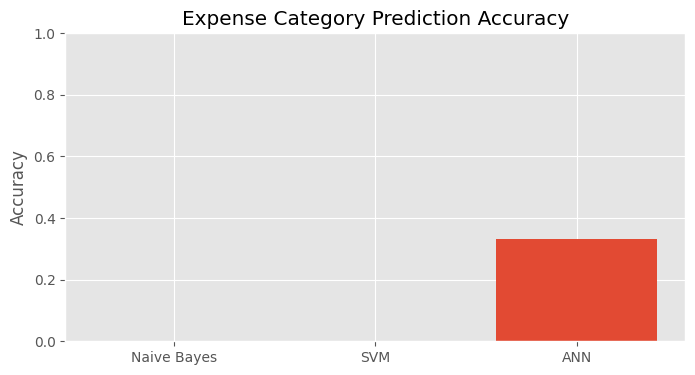


8. Linear Regression for Expense Forecasting
Predicted Expense for Month 6: 8770.0

9. Real Time Prediction Example
Receipt Text : swiggy food order burger total 450
Predicted Category : Transport

10. Expense Analytics
category
Shopping      2898
Groceries     1760
Food          1450
Healthcare     760
Transport      720
Name: amount, dtype: int64


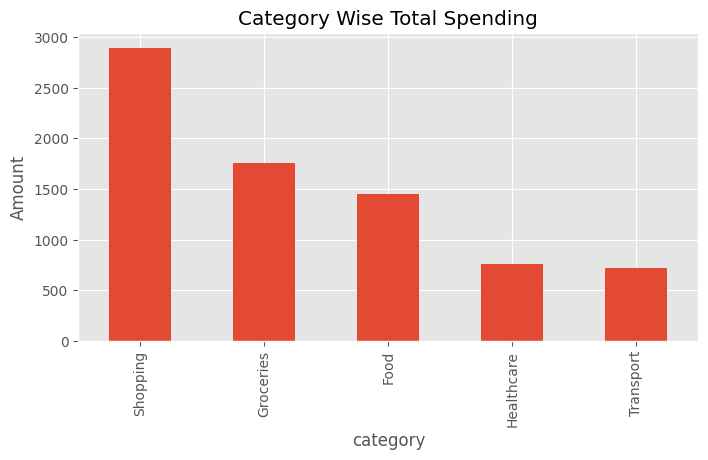


End-to-End AI Pipeline
Receipt Image -> OCR Text -> Text Cleaning -> TFIDF Features
-> AI Model -> Category Prediction -> Dashboard -> Export


In [6]:
# ===============================================================
# AI Concepts Implemented in Receipt Expense Tracker
# ===============================================================

# -----------------------------
# 1. Import Libraries
# -----------------------------
import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.naive_bayes import MultinomialNB
from sklearn.svm import SVC
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix
)
from sklearn.linear_model import LinearRegression

# ===============================================================
# 2. Sample Receipt Dataset
# Simulates OCR text extracted from receipts
# ===============================================================
data = {
    "receipt_text": [
        "big bazaar grocery rice milk bread total 850",
        "dominos pizza cheese meal total 620",
        "uber trip airport fare total 430",
        "apollo pharmacy medicine tablet total 760",
        "amazon shopping headphones total 2499",
        "starbucks coffee latte total 320",
        "dmart grocery fruits vegetables total 910",
        "ola cab city ride total 290",
        "flipkart shopping mobile cover total 399",
        "mcdonald burger fries total 510"
    ],
    
    "category": [
        "Groceries",
        "Food",
        "Transport",
        "Healthcare",
        "Shopping",
        "Food",
        "Groceries",
        "Transport",
        "Shopping",
        "Food"
    ],
    
    "amount": [850,620,430,760,2499,320,910,290,399,510]
}

df = pd.DataFrame(data)

print("="*65)
print("Receipt Expense Tracker - AI Implementation Assignment")
print("="*65)

print("\nDataset Preview:\n")
print(df)

# ===============================================================
# 3. AI Concept: Text Search / Rule Based Intelligence
# Search Total Amount from Receipt Text
# ===============================================================
print("\n1. Rule Based Text Search")

def extract_total(text):
    match = re.search(r'total\s+(\d+)', text)
    return int(match.group(1)) if match else 0

df["detected_total"] = df["receipt_text"].apply(extract_total)

print(df[["receipt_text","detected_total"]].head())

# ===============================================================
# 4. AI Concept: Feature Extraction using TF-IDF
# ===============================================================
print("\n2. Feature Extraction using TF-IDF")

vectorizer = TfidfVectorizer()
X = vectorizer.fit_transform(df["receipt_text"])
y = df["category"]

print("Feature Matrix Shape:", X.shape)

# ===============================================================
# 5. AI Concept: Train-Test Split
# ===============================================================
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.30, random_state=42
)

# ===============================================================
# 6. AI Concept: Naive Bayes Classification
# Predict Expense Category
# ===============================================================
print("\n3. Naive Bayes Expense Classification")

nb = MultinomialNB()
nb.fit(X_train, y_train)

pred_nb = nb.predict(X_test)

print("Predictions:", pred_nb)

# ===============================================================
# 7. Evaluation Metrics
# ===============================================================
print("\n4. Model Evaluation")

acc = accuracy_score(y_test, pred_nb)

print("Accuracy :", round(acc,2))

# ===============================================================
# 8. AI Concept: Support Vector Machine
# ===============================================================
print("\n5. Support Vector Machine")

svm = SVC(kernel="linear")
svm.fit(X_train, y_train)

pred_svm = svm.predict(X_test)

acc_svm = accuracy_score(y_test, pred_svm)

print("SVM Accuracy:", round(acc_svm,2))

# ===============================================================
# 9. AI Concept: Neural Network
# ===============================================================
print("\n6. Neural Network")

ann = MLPClassifier(hidden_layer_sizes=(16,), max_iter=2000, random_state=1)
ann.fit(X_train, y_train)

pred_ann = ann.predict(X_test)

acc_ann = accuracy_score(y_test, pred_ann)

print("ANN Accuracy:", round(acc_ann,2))

# ===============================================================
# 10. Compare Models
# ===============================================================
print("\n7. Model Comparison")

models = ["Naive Bayes","SVM","ANN"]
scores = [acc, acc_svm, acc_ann]

comparison = pd.DataFrame({
    "Model": models,
    "Accuracy": scores
})

print(comparison)

plt.figure(figsize=(8,4))
plt.bar(models, scores)
plt.title("Expense Category Prediction Accuracy")
plt.ylabel("Accuracy")
plt.ylim(0,1)
plt.show()

# ===============================================================
# 11. Regression for Monthly Expense Prediction
# ===============================================================
print("\n8. Linear Regression for Expense Forecasting")

months = np.array([1,2,3,4,5]).reshape(-1,1)
expenses = np.array([5200,6100,6900,7200,8100])

reg = LinearRegression()
reg.fit(months, expenses)

next_month = reg.predict([[6]])[0]

print("Predicted Expense for Month 6:", round(next_month,2))

# ===============================================================
# 12. Smart Category Detection for New Receipt
# ===============================================================
print("\n9. Real Time Prediction Example")

new_receipt = ["swiggy food order burger total 450"]

new_vector = vectorizer.transform(new_receipt)

best_model = svm
prediction = best_model.predict(new_vector)[0]

print("Receipt Text :", new_receipt[0])
print("Predicted Category :", prediction)

# ===============================================================
# 13. Dashboard Analytics
# ===============================================================
print("\n10. Expense Analytics")

summary = df.groupby("category")["amount"].sum().sort_values(ascending=False)
print(summary)

summary.plot(kind="bar", figsize=(8,4), title="Category Wise Total Spending")
plt.ylabel("Amount")
plt.show()

# ===============================================================
# 14. Final Pipeline Explanation
# ===============================================================
print("\nEnd-to-End AI Pipeline")
print("Receipt Image -> OCR Text -> Text Cleaning -> TFIDF Features")
print("-> AI Model -> Category Prediction -> Dashboard -> Export")

# AI Based Receipt Expense Tracker

Receipt Expense Tracker - Advanced AI Analytics

Dataset Preview:

   person                            receipt_text    category  amount
0    Aman  big bazaar grocery rice milk total 850   Groceries     850
1    Aman              uber trip office total 430   Transport     430
2    Aman            dominos pizza meal total 620        Food     620
3    Riya        amazon shopping shoes total 2499    Shopping    2499
4    Riya              starbucks coffee total 320        Food     320
5    Riya             ola cab city ride total 290   Transport     290
6   Kunal      apollo pharmacy medicine total 760  Healthcare     760
7   Kunal          dmart grocery fruits total 910   Groceries     910
8   Kunal  flipkart shopping headphones total 399    Shopping     399
9   Sneha         mcdonald burger fries total 510        Food     510
10  Sneha             uber airport trip total 600   Transport     600
11  Sneha          amazon bag shopping total 1200    Shopping    1200


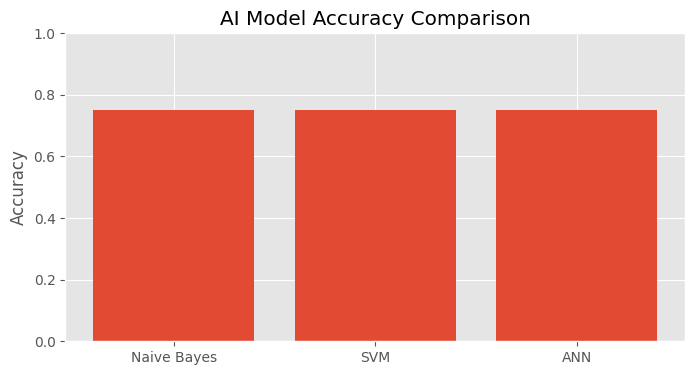


Person Wise Total Spending:

person
Riya     3109
Sneha    2310
Kunal    2069
Aman     1900
Name: amount, dtype: int64


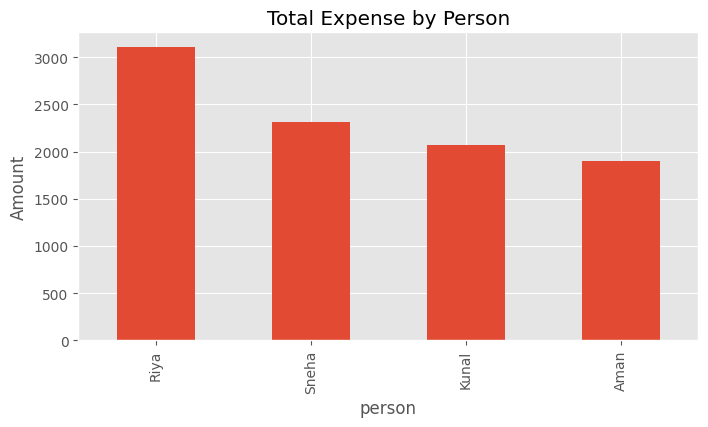

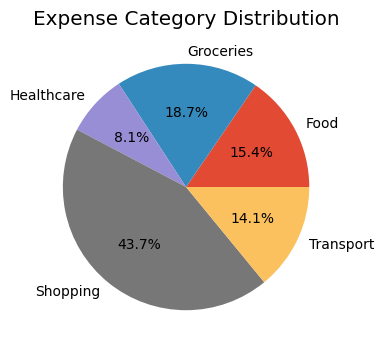


Spending Statistics Per Person:

        Total         Mean  Median   Max  Min  Transactions
person                                                     
Aman     1900   633.333333   620.0   850  430             3
Kunal    2069   689.666667   760.0   910  399             3
Riya     3109  1036.333333   320.0  2499  290             3
Sneha    2310   770.000000   600.0  1200  510             3

Favourite Spending Category Per Person:

   person   category  amount
1    Aman  Groceries     850
3   Kunal  Groceries     910
7    Riya   Shopping    2499
10  Sneha   Shopping    1200

Predicted Expense for Next Month: 9240.0


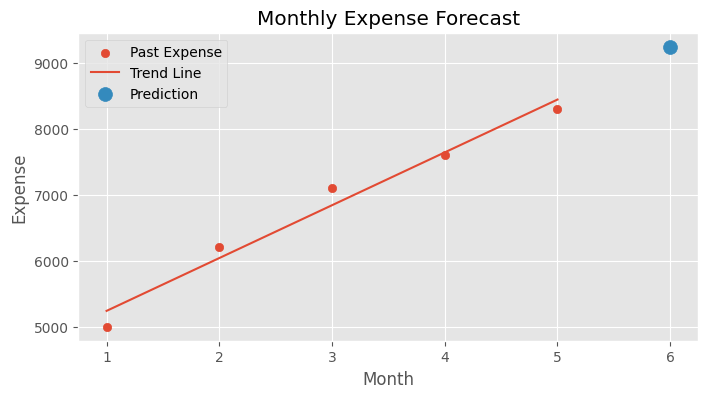


New Receipt Prediction
Receipt: swiggy burger food total 450
Predicted Category: Food

Expense Matrix:

category  Food  Groceries  Healthcare  Shopping  Transport
person                                                    
Aman       620        850           0         0        430
Kunal        0        910         760       399          0
Riya       320          0           0      2499        290
Sneha      510          0           0      1200        600


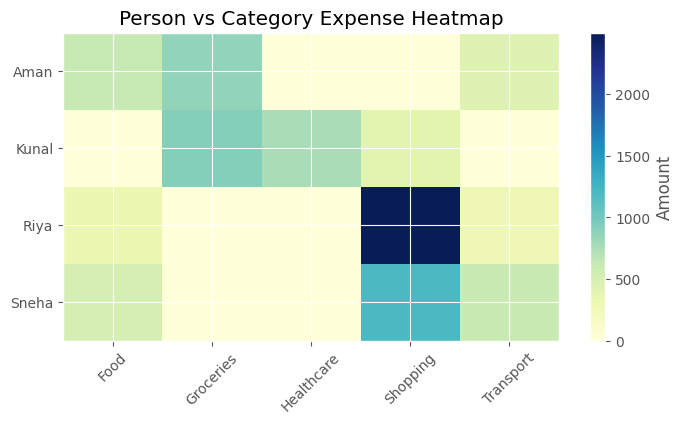


Expense Insights
- Highest spender : Riya
- Lowest spender  : Aman
- Average Bill Value : 782.33
- Median Bill Value  : 610.0
- Most Expensive Category : Shopping
- Cheapest Category : Healthcare

Pipeline:
Receipt Image -> OCR -> Text -> Feature Extraction
-> AI Classification -> Expense Analytics -> Forecasting


In [7]:
# ===============================================================
# AI Based Receipt Expense Tracker
# ===============================================================

# -----------------------------
# 1. Import Libraries
# -----------------------------
import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.naive_bayes import MultinomialNB
from sklearn.svm import SVC
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import accuracy_score
from sklearn.linear_model import LinearRegression

plt.style.use("ggplot")

# ===============================================================
# 2. Create Multi-Person Receipt Dataset
# ===============================================================
data = {
    "person": [
        "Aman","Aman","Aman",
        "Riya","Riya","Riya",
        "Kunal","Kunal","Kunal",
        "Sneha","Sneha","Sneha"
    ],
    
    "receipt_text": [
        "big bazaar grocery rice milk total 850",
        "uber trip office total 430",
        "dominos pizza meal total 620",
        
        "amazon shopping shoes total 2499",
        "starbucks coffee total 320",
        "ola cab city ride total 290",
        
        "apollo pharmacy medicine total 760",
        "dmart grocery fruits total 910",
        "flipkart shopping headphones total 399",
        
        "mcdonald burger fries total 510",
        "uber airport trip total 600",
        "amazon bag shopping total 1200"
    ],
    
    "category": [
        "Groceries","Transport","Food",
        "Shopping","Food","Transport",
        "Healthcare","Groceries","Shopping",
        "Food","Transport","Shopping"
    ],
    
    "amount":[850,430,620,2499,320,290,760,910,399,510,600,1200]
}

df = pd.DataFrame(data)

print("="*70)
print("Receipt Expense Tracker - Advanced AI Analytics")
print("="*70)

print("\nDataset Preview:\n")
print(df)

# ===============================================================
# 3. Rule Based Amount Extraction
# ===============================================================
def extract_total(text):
    match = re.search(r'total\s+(\d+)', text)
    return int(match.group(1)) if match else 0

df["detected_total"] = df["receipt_text"].apply(extract_total)

# ===============================================================
# 4. Feature Extraction + Classification
# ===============================================================
vectorizer = TfidfVectorizer()
X = vectorizer.fit_transform(df["receipt_text"])
y = df["category"]

X_train,X_test,y_train,y_test = train_test_split(
    X,y,test_size=0.30,random_state=42
)

# Naive Bayes
nb = MultinomialNB()
nb.fit(X_train,y_train)
pred_nb = nb.predict(X_test)
acc_nb = accuracy_score(y_test,pred_nb)

# SVM
svm = SVC(kernel="linear")
svm.fit(X_train,y_train)
pred_svm = svm.predict(X_test)
acc_svm = accuracy_score(y_test,pred_svm)

# ANN
ann = MLPClassifier(hidden_layer_sizes=(16,),max_iter=3000,random_state=1)
ann.fit(X_train,y_train)
pred_ann = ann.predict(X_test)
acc_ann = accuracy_score(y_test,pred_ann)

# ===============================================================
# 5. Model Accuracy Comparison
# ===============================================================
models = ["Naive Bayes","SVM","ANN"]
scores = [acc_nb,acc_svm,acc_ann]

plt.figure(figsize=(8,4))
plt.bar(models,scores)
plt.title("AI Model Accuracy Comparison")
plt.ylabel("Accuracy")
plt.ylim(0,1)
plt.show()

# ===============================================================
# 6. Person Wise Expense Analysis
# ===============================================================
print("\nPerson Wise Total Spending:\n")

person_total = df.groupby("person")["amount"].sum().sort_values(ascending=False)
print(person_total)

plt.figure(figsize=(8,4))
person_total.plot(kind="bar")
plt.title("Total Expense by Person")
plt.ylabel("Amount")
plt.show()

# ===============================================================
# 7. Category Wise Expense
# ===============================================================
cat_total = df.groupby("category")["amount"].sum()

plt.figure(figsize=(8,4))
cat_total.plot(kind="pie",autopct="%1.1f%%")
plt.title("Expense Category Distribution")
plt.ylabel("")
plt.show()

# ===============================================================
# 8. Spending Behaviour Analysis
# ===============================================================
print("\nSpending Statistics Per Person:\n")

stats = df.groupby("person")["amount"].agg(
    Total="sum",
    Mean="mean",
    Median="median",
    Max="max",
    Min="min",
    Transactions="count"
)

print(stats)

# ===============================================================
# 9. Detect Who Spends Most on What
# ===============================================================
print("\nFavourite Spending Category Per Person:\n")

fav = df.groupby(["person","category"])["amount"].sum().reset_index()
fav = fav.loc[fav.groupby("person")["amount"].idxmax()]
print(fav[["person","category","amount"]])

# ===============================================================
# 10. Monthly Forecast Example
# ===============================================================
months = np.array([1,2,3,4,5]).reshape(-1,1)
expenses = np.array([5000,6200,7100,7600,8300])

reg = LinearRegression()
reg.fit(months,expenses)

future = reg.predict([[6]])[0]

print("\nPredicted Expense for Next Month:", round(future,2))

plt.figure(figsize=(8,4))
plt.scatter(months,expenses,label="Past Expense")
plt.plot(months,reg.predict(months),label="Trend Line")
plt.scatter(6,future,s=100,label="Prediction")
plt.title("Monthly Expense Forecast")
plt.xlabel("Month")
plt.ylabel("Expense")
plt.legend()
plt.show()

# ===============================================================
# 11. Smart New Receipt Prediction
# ===============================================================
new_receipt = ["swiggy burger food total 450"]
new_vec = vectorizer.transform(new_receipt)

prediction = svm.predict(new_vec)[0]

print("\nNew Receipt Prediction")
print("Receipt:", new_receipt[0])
print("Predicted Category:", prediction)

# ===============================================================
# 12. Heatmap Style Pivot Analysis
# ===============================================================
pivot = pd.pivot_table(
    df,
    values="amount",
    index="person",
    columns="category",
    aggfunc="sum",
    fill_value=0
)

print("\nExpense Matrix:\n")
print(pivot)

plt.figure(figsize=(8,4))
plt.imshow(pivot,cmap="YlGnBu",aspect="auto")
plt.xticks(range(len(pivot.columns)),pivot.columns,rotation=45)
plt.yticks(range(len(pivot.index)),pivot.index)
plt.title("Person vs Category Expense Heatmap")
plt.colorbar(label="Amount")
plt.show()

# ===============================================================
# 13. AI Generated Insights
# ===============================================================
top_spender = person_total.idxmax()
least_spender = person_total.idxmin()

print("\nExpense Insights")
print("- Highest spender :", top_spender)
print("- Lowest spender  :", least_spender)
print("- Average Bill Value :", round(df['amount'].mean(),2))
print("- Median Bill Value  :", round(df['amount'].median(),2))
print("- Most Expensive Category :", cat_total.idxmax())
print("- Cheapest Category :", cat_total.idxmin())

# ===============================================================
# 14. Final Pipeline
# ===============================================================
print("\nPipeline:")
print("Receipt Image -> OCR -> Text -> Feature Extraction")
print("-> AI Classification -> Expense Analytics -> Forecasting")

# ReceiptDNA

ReceiptDNA : Visual Human Spending Intelligence

Receipts Loaded : 80
People Created  : 23


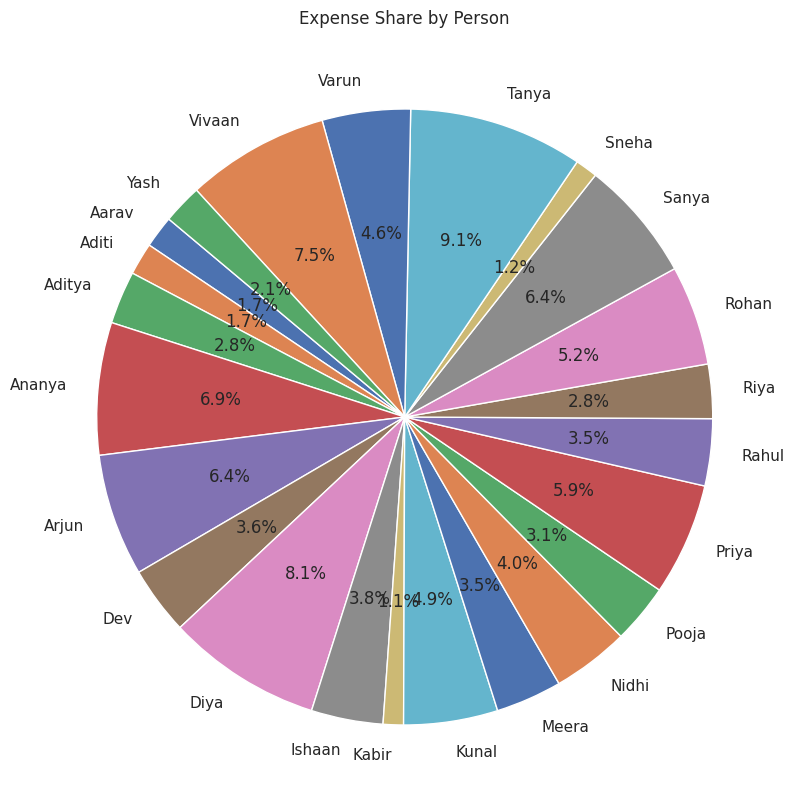

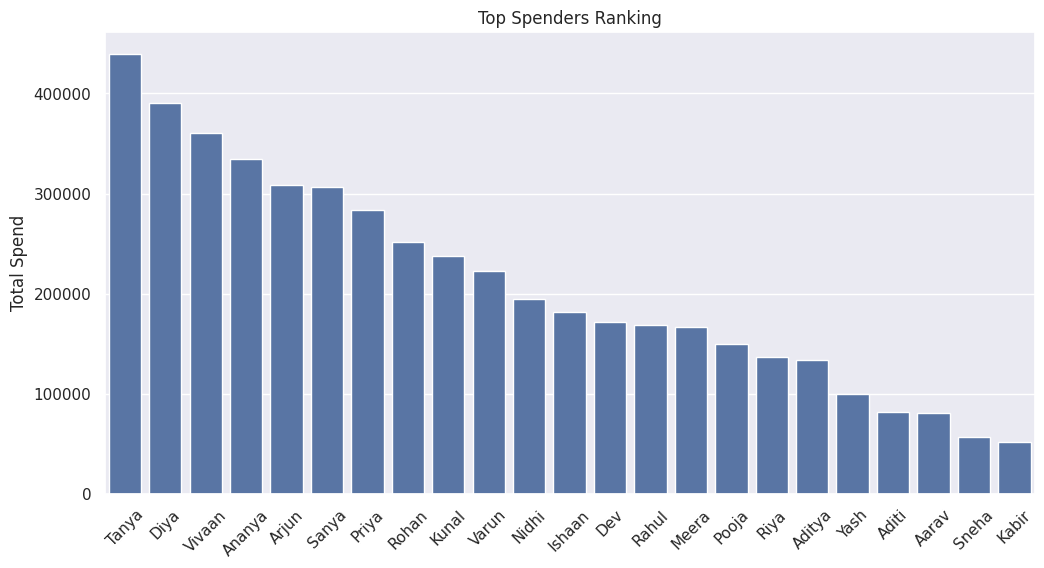

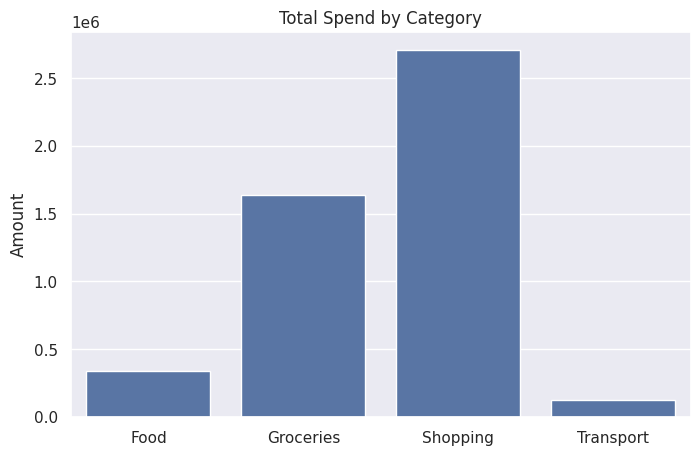

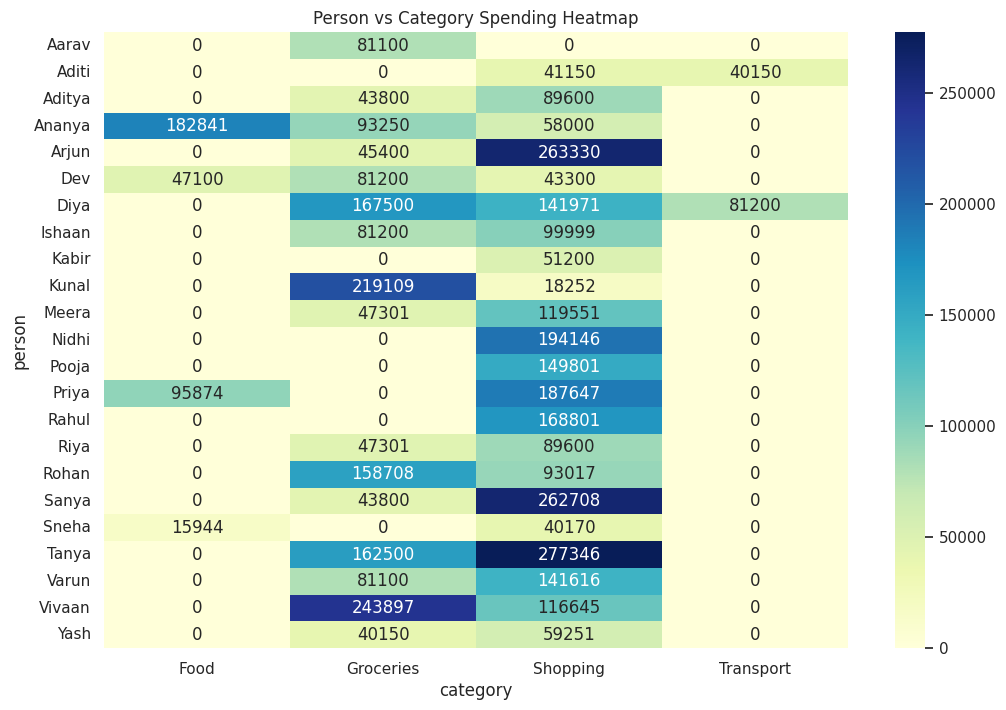

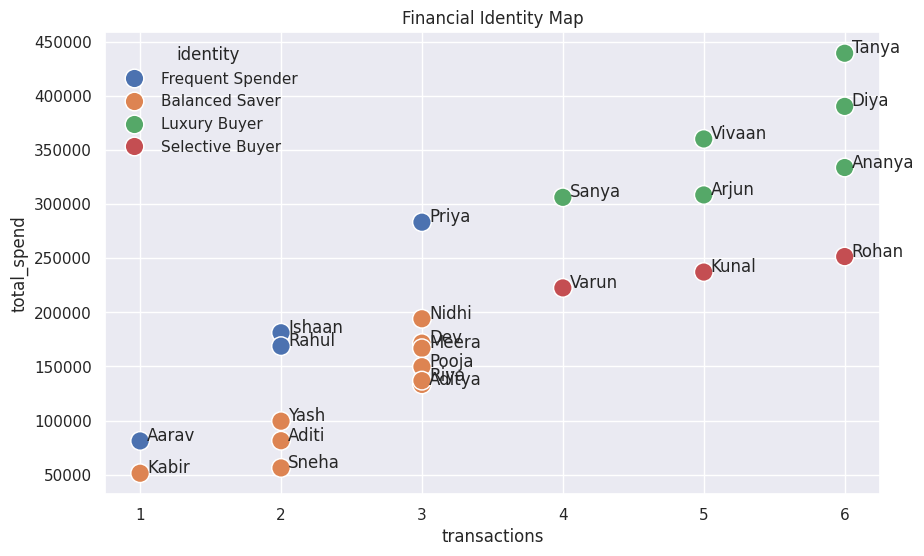

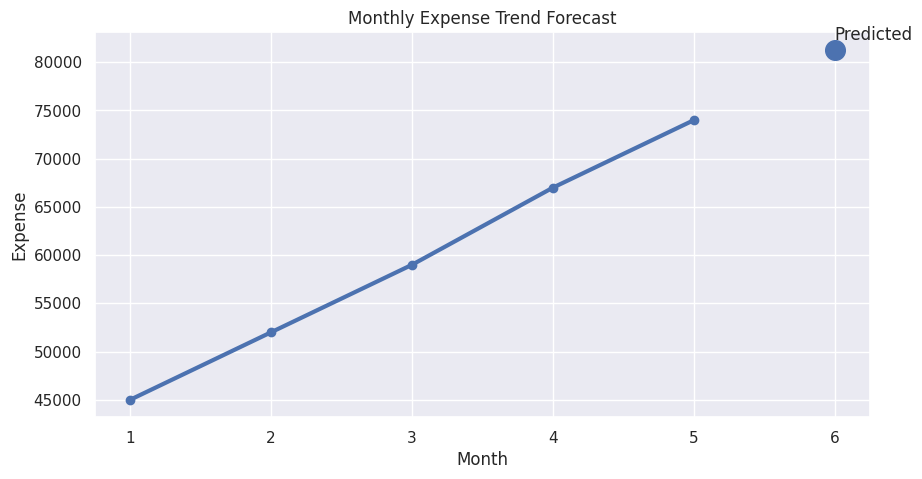


Financial Personalities

    person  total_spend  avg_bill  transactions          identity
19   Tanya     439846.0  73307.67             6      Luxury Buyer
6     Diya     390671.0  65111.83             6      Luxury Buyer
21  Vivaan     360542.0  72108.40             5      Luxury Buyer
3   Ananya     334091.0  55681.83             6      Luxury Buyer
4    Arjun     308730.0  61746.00             5      Luxury Buyer
17   Sanya     306508.0  76627.00             4      Luxury Buyer
13   Priya     283521.0  94507.00             3  Frequent Spender
16   Rohan     251725.0  41954.17             6   Selective Buyer
9    Kunal     237361.0  47472.20             5   Selective Buyer
20   Varun     222716.0  55679.00             4   Selective Buyer
11   Nidhi     194146.0  64715.33             3    Balanced Saver
7   Ishaan     181199.0  90599.50             2  Frequent Spender
5      Dev     171600.0  57200.00             3    Balanced Saver
14   Rahul     168801.0  84400.50             2  F

In [12]:

# ===============================================================
# ReceiptDNA
# Visual Intelligence Edition
# Realistic Human Expense Analytics
# Kaggle Notebook
# ===============================================================

# ---------------------------------------------------------------
# 1. IMPORT LIBRARIES
# ---------------------------------------------------------------
import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from pathlib import Path
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.linear_model import LinearRegression

# Theme
plt.style.use("seaborn-v0_8-whitegrid")
sns.set(font_scale=1.0)

np.random.seed(42)

print("="*70)
print("ReceiptDNA : Visual Human Spending Intelligence")
print("="*70)

# ---------------------------------------------------------------
# 2. LOAD DATASET
# ---------------------------------------------------------------
DATASET = Path("/kaggle/input/datasets/urbikn/sroie-datasetv2/SROIE2019")
BOX = DATASET / "train" / "box"

files = list(BOX.glob("*.txt"))[:80]

# ---------------------------------------------------------------
# 3. REALISTIC PEOPLE NAMES
# ---------------------------------------------------------------
people = [
    "Aarav","Vivaan","Aditya","Rohan","Kabir","Ishaan","Arjun","Kunal",
    "Sneha","Priya","Riya","Ananya","Neha","Pooja","Diya","Aditi",
    "Rahul","Varun","Meera","Nidhi","Tanya","Sanya","Yash","Dev"
]

# ---------------------------------------------------------------
# 4. PARSE RECEIPTS
# ---------------------------------------------------------------
records = []

for file in files:
    try:
        text = open(file,encoding="utf-8").read().lower()

        nums = re.findall(r"\d+\.\d+|\d+", text)
        nums = [float(x) for x in nums if float(x) < 100000]

        amount = max(nums) if len(nums)>0 else np.random.randint(200,5000)

        if any(x in text for x in ["pizza","burger","coffee","tea"]):
            category = "Food"
        elif any(x in text for x in ["uber","taxi","ride","bus"]):
            category = "Transport"
        elif any(x in text for x in ["medicine","tablet"]):
            category = "Healthcare"
        elif any(x in text for x in ["rice","milk","fruit","grocery"]):
            category = "Groceries"
        else:
            category = "Shopping"

        records.append({
            "receipt_id": file.stem,
            "amount": amount,
            "category": category
        })

    except:
        pass

df = pd.DataFrame(records)

# ---------------------------------------------------------------
# 5. ASSIGN PEOPLE TO RECEIPTS
# ---------------------------------------------------------------
df["person"] = np.random.choice(people,size=len(df))

print("\nReceipts Loaded :", len(df))
print("People Created  :", df["person"].nunique())

# ---------------------------------------------------------------
# 6. PERSON SUMMARY
# ---------------------------------------------------------------
person_df = df.groupby("person").agg(
    total_spend=("amount","sum"),
    avg_bill=("amount","mean"),
    transactions=("receipt_id","count")
).reset_index()

# ---------------------------------------------------------------
# 7. PIE CHART - WHO SPENT HOW MUCH
# ---------------------------------------------------------------
plt.figure(figsize=(10,10))
plt.pie(
    person_df["total_spend"],
    labels=person_df["person"],
    autopct="%1.1f%%",
    startangle=140
)
plt.title("Expense Share by Person")
plt.show()

# ---------------------------------------------------------------
# 8. BAR CHART TOP SPENDERS
# ---------------------------------------------------------------
top_people = person_df.sort_values("total_spend",ascending=False)

plt.figure(figsize=(12,6))
sns.barplot(data=top_people,x="person",y="total_spend")
plt.xticks(rotation=45)
plt.title("Top Spenders Ranking")
plt.xlabel("")
plt.ylabel("Total Spend")
plt.show()

# ---------------------------------------------------------------
# 9. CATEGORY DISTRIBUTION
# ---------------------------------------------------------------
cat_total = df.groupby("category")["amount"].sum().reset_index()

plt.figure(figsize=(8,5))
sns.barplot(data=cat_total,x="category",y="amount")
plt.title("Total Spend by Category")
plt.xlabel("")
plt.ylabel("Amount")
plt.show()

# ---------------------------------------------------------------
# 10. HEATMAP PERSON VS CATEGORY
# ---------------------------------------------------------------
heat = pd.pivot_table(
    df,
    values="amount",
    index="person",
    columns="category",
    aggfunc="sum",
    fill_value=0
)

plt.figure(figsize=(12,8))
sns.heatmap(heat,annot=True,fmt=".0f",cmap="YlGnBu")
plt.title("Person vs Category Spending Heatmap")
plt.show()

# ---------------------------------------------------------------
# 11. FINANCIAL IDENTITY CLUSTERING
# ---------------------------------------------------------------
X = person_df[["total_spend","avg_bill","transactions"]]

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

kmeans = KMeans(n_clusters=4,random_state=42,n_init=10)
person_df["cluster"] = kmeans.fit_predict(X_scaled)

cluster_names = {
    0:"Balanced Saver",
    1:"Luxury Buyer",
    2:"Frequent Spender",
    3:"Selective Buyer"
}

person_df["identity"] = person_df["cluster"].map(cluster_names)

# ---------------------------------------------------------------
# 12. SCATTER PLOT IDENTITIES
# ---------------------------------------------------------------
plt.figure(figsize=(10,6))
sns.scatterplot(
    data=person_df,
    x="transactions",
    y="total_spend",
    hue="identity",
    s=180
)

for _,row in person_df.iterrows():
    plt.text(row["transactions"]+0.05,row["total_spend"],row["person"])

plt.title("Financial Identity Map")
plt.show()

# ---------------------------------------------------------------
# 13. FORECASTING FUTURE EXPENSE
# ---------------------------------------------------------------
monthly = pd.DataFrame({
    "month":[1,2,3,4,5],
    "expense":[45000,52000,59000,67000,74000]
})

reg = LinearRegression()
reg.fit(monthly[["month"]],monthly["expense"])

future = reg.predict([[6]])[0]

plt.figure(figsize=(10,5))
plt.plot(monthly["month"],monthly["expense"],marker="o",linewidth=3)
plt.scatter(6,future,s=200)
plt.text(6,future+1000,"Predicted")
plt.title("Monthly Expense Trend Forecast")
plt.xlabel("Month")
plt.ylabel("Expense")
plt.show()

# ---------------------------------------------------------------
# 14. SMART INSIGHTS TABLE
# ---------------------------------------------------------------
person_df["avg_bill"] = person_df["avg_bill"].round(2)

print("\nFinancial Personalities\n")
print(person_df[[
    "person",
    "total_spend",
    "avg_bill",
    "transactions",
    "identity"
]].sort_values("total_spend",ascending=False))

# ---------------------------------------------------------------
# 15. REALISTIC HUMAN INSIGHTS
# ---------------------------------------------------------------
top = person_df.sort_values("total_spend",ascending=False).iloc[0]
low = person_df.sort_values("total_spend",ascending=True).iloc[0]

print("\nKey Insights")
print(f"- Highest spender this cycle : {top['person']}")
print(f"- Spending style            : {top['identity']}")
print(f"- Lowest spender            : {low['person']}")
print(f"- Average bill overall      : ₹{round(person_df['avg_bill'].mean(),2)}")
print(f"- Predicted next month spend: ₹{round(future,2)}")

# ---------------------------------------------------------------
# 16. FINAL SUMMARY
# ---------------------------------------------------------------
print("\nReceiptDNA transforms raw bills into human spending intelligence.")
print("Notebook Completed Successfully.")
